## Project: Predicting GenZ Music Energy Via Psychographic And Behavioural Indicator Analysis

---
### 📌 Problem Statement
New platforms struggle to recommend the right music to GenZ users without prior listening history, which often leads to poor recommendations, user frustration, and app abandonment. This project aims to predict a person’s music energy based on their current mood, personality traits, and daily digital habits.

### 📊 Objective
To analyze primary data collected via Google Forms and build a Machine Learning model that identifies key factors contributing to music energy.

### 1. Data Loading and Cleaning
In this section, we load the dataset, remove unnecessary index columns, and rename the verbose survey questions into concise variable names for easier manipulation.

In [1]:
import pandas as pd

df = pd.read_csv("GenZ_Lifestyle_And_Music_Preferences_Survey.csv")
df.drop(df.columns[[0]], axis = 1, inplace = True)
df.head()

,Gender:,Age Group:,1. How would you describe your personality type?,2. When are you most often actively listening to music?,3. How do you approach your daily tasks and schedule?,4. How would you describe the general pace of your lifestyle?,5. What is your most frequent state of mind when you actively seek out music?,6. How deeply do you usually feel the emotions of the people around you or characters in a movie/book?,"7. When you listen to a new song, what does your brain naturally focus on first?",8. What type of music do you lean towards on a daily basis?
0,Male,18 - 21 years,"Conscientiousness (Responsible, Organized, Dis...","Working out, playing sports, or getting ready ...",Somewhat organized,"Steady, predictable, and focused on one thing ...",Energetic / Hyped,Moderately,"The beat, the bass, or the overall rhythm.","High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)"
1,Male,14 - 17 years,"Openness to Experience (Creative, Curious, Ima...","Working out, playing sports, or getting ready ...",Highly spontaneous,"Fast-paced, constantly moving, or frequently m...",Stressed / Overwelmed,Very deeply,"The beat, the bass, or the overall rhythm.","High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)"
2,Male,18 - 21 years,"Agreeableness (Friendly, Cooperative, Empathetic)","Studying, working, reading, or trying to sleep.",Somewhat organized,"Fast-paced, constantly moving, or frequently m...",Calm / Need to Focus,Moderately,"The beat, the bass, or the overall rhythm.","High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)"
3,Female,18 - 21 years,"Neuroticism (Emotional Instability, Anxiety, M...","Commuting, walking, or doing household chores.",Highly spontaneous,"Fast-paced, constantly moving, or frequently m...",Calm / Need to Focus,Very deeply,"The lyrics, the vocals, or the overall melody.","Low-Energy (Lo-Fi, Classical, Acoustic, Indie,..."
4,Female,18 - 21 years,"Neuroticism (Emotional Instability, Anxiety, M...","Commuting, walking, or doing household chores.",Somewhat organized,"Fast-paced, constantly moving, or frequently m...",Sad / Hurt,Moderately,"The lyrics, the vocals, or the overall melody.","Low-Energy (Lo-Fi, Classical, Acoustic, Indie,..."


In [2]:
print("No. of Rows and Columns in the dataset:",df.shape)

No. of Rows and Columns in the dataset: (112, 10)


In [3]:
df.rename(columns = {
    "Gender:": "Gender",
    "Age Group:": "Age_Group",
    "1. How would you describe your personality type?": "Personality_Type",
    "2. When are you most often actively listening to music?": "Listening_Context",
    "3. How do you approach your daily tasks and schedule?": "Organization_Level",
    "4. How would you describe the general pace of your lifestyle?": "Lifestyle_Pace",
    "5. What is your most frequent state of mind when you actively seek out music?": "Listening_Mood",
    "6. How deeply do you usually feel the emotions of the people around you or characters in a movie/book?": "Empathy_Level",
    "7. When you listen to a new song, what does your brain naturally focus on first?": "Music_Focus_Element",
    "8. What type of music do you lean towards on a daily basis?": "Music_Energy"
}, inplace = True)

df.head()

,Gender,Age_Group,Personality_Type,Listening_Context,Organization_Level,Lifestyle_Pace,Listening_Mood,Empathy_Level,Music_Focus_Element,Music_Energy
0,Male,18 - 21 years,"Conscientiousness (Responsible, Organized, Dis...","Working out, playing sports, or getting ready ...",Somewhat organized,"Steady, predictable, and focused on one thing ...",Energetic / Hyped,Moderately,"The beat, the bass, or the overall rhythm.","High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)"
1,Male,14 - 17 years,"Openness to Experience (Creative, Curious, Ima...","Working out, playing sports, or getting ready ...",Highly spontaneous,"Fast-paced, constantly moving, or frequently m...",Stressed / Overwelmed,Very deeply,"The beat, the bass, or the overall rhythm.","High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)"
2,Male,18 - 21 years,"Agreeableness (Friendly, Cooperative, Empathetic)","Studying, working, reading, or trying to sleep.",Somewhat organized,"Fast-paced, constantly moving, or frequently m...",Calm / Need to Focus,Moderately,"The beat, the bass, or the overall rhythm.","High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)"
3,Female,18 - 21 years,"Neuroticism (Emotional Instability, Anxiety, M...","Commuting, walking, or doing household chores.",Highly spontaneous,"Fast-paced, constantly moving, or frequently m...",Calm / Need to Focus,Very deeply,"The lyrics, the vocals, or the overall melody.","Low-Energy (Lo-Fi, Classical, Acoustic, Indie,..."
4,Female,18 - 21 years,"Neuroticism (Emotional Instability, Anxiety, M...","Commuting, walking, or doing household chores.",Somewhat organized,"Fast-paced, constantly moving, or frequently m...",Sad / Hurt,Moderately,"The lyrics, the vocals, or the overall melody.","Low-Energy (Lo-Fi, Classical, Acoustic, Indie,..."


In [4]:
df.isnull().sum()

Gender                 0
Age_Group              0
Personality_Type       0
Listening_Context      0
Organization_Level     0
Lifestyle_Pace         0
Listening_Mood         0
Empathy_Level          0
Music_Focus_Element    0
Music_Energy           0
dtype: int64

### 2. Exploratory Data Analysis (EDA)
#### 2.1 Demographic and Target Distribution
We visualize the distribution of Gender, Age Groups, and our target variable (Music Energy) to understand the composition of our dataset using pie charts.

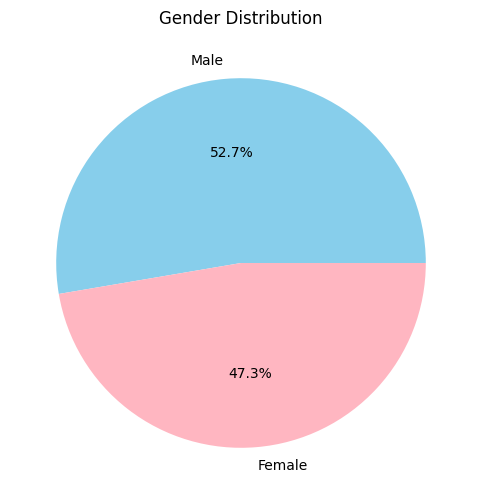

In [5]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()

plt.figure(figsize = (6, 6))
plt.pie(gender_counts, labels = gender_counts.index, autopct = '%1.1f%%', colors = ['skyblue', 'lightpink'])
plt.title("Gender Distribution")
plt.show()

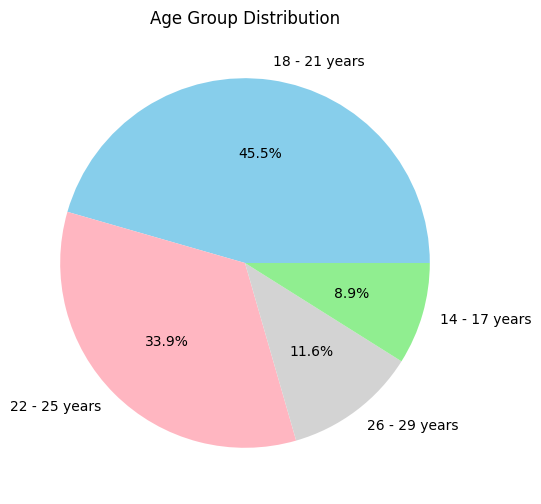

In [6]:
age_counts = df['Age_Group'].value_counts()

plt.figure(figsize = (6, 6))
plt.pie(age_counts, labels = age_counts.index, autopct = '%1.1f%%', colors = ['skyblue', 'lightpink', 'lightgrey', 'lightgreen', 'orange'])
plt.title("Age Group Distribution")
plt.show()

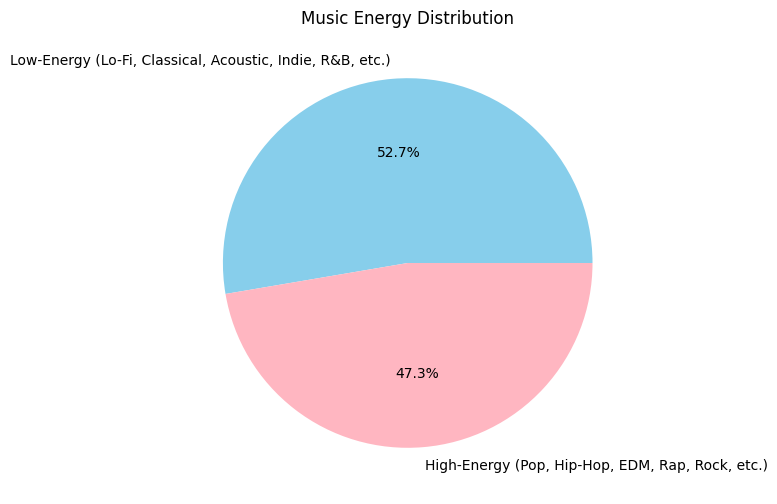

In [7]:
music_counts = df['Music_Energy'].value_counts()

plt.figure(figsize = (6, 6))
plt.pie(music_counts, labels = music_counts.index, autopct = '%1.1f%%', colors = ['skyblue', 'lightpink'])
plt.title("Music Energy Distribution")
plt.show()

### 3. Data Preprocessing
#### 3.1 Label Encoding
- Machine learning algorithms require numerical input.   
- Here, we have explicitly mapped the dataset features to convert categorical into numeric format.  
- This is done to maintain the level of values in a feature.

In [8]:
map1 = {
    "Male": 0, 
    "Female": 1
}
df["Gender"] = df["Gender"].map(map1)

map2 = {
    "14 - 17 years": 0, 
    "18 - 21 years": 1,
    "22 - 25 years": 2,
    "26 - 29 years": 3
}
df["Age_Group"] = df["Age_Group"].map(map2)

map3 = {
    "Openness to Experience (Creative, Curious, Imaginative)": 0, 
    "Conscientiousness (Responsible, Organized, Disciplined)": 1, 
    "Extraversion (Outgoing, Energetic, Social)": 2,
    "Agreeableness (Friendly, Cooperative, Empathetic)": 3,
    "Neuroticism (Emotional Instability, Anxiety, Mood Swings)": 4
}
df["Personality_Type"] = df["Personality_Type"].map(map3)

map4 = {
    "Working out, playing sports, or getting ready to go out.": 0, 
    "Commuting, walking, or doing household chores.": 1, 
    "Studying, working, reading, or trying to sleep.": 2
}
df["Listening_Context"] = df["Listening_Context"].map(map4)

map5 = {
    "Highly spontaneous": 0, 
    "Somewhat organized": 1, 
    "Highly structured": 2
}
df["Organization_Level"] = df["Organization_Level"].map(map5)

map6 = {
    "Fast-paced, constantly moving, or frequently multitasking.": 0, 
    "Steady, predictable, and focused on one thing at a time.": 1, 
    "Slow, relaxed, or highly laid-back.": 2
}
df["Lifestyle_Pace"] = df["Lifestyle_Pace"].map(map6)

map7 = {
    "Stressed / Overwelmed": 0, 
    "Energetic / Hyped": 1, 
    "Sad / Hurt": 2,
    "Calm / Need to Focus": 3
}
df["Listening_Mood"] = df["Listening_Mood"].map(map7)

map8 = {
    "Very deeply": 0, 
    "Moderately": 1, 
    "Rarely": 2
}
df["Empathy_Level"] = df["Empathy_Level"].map(map8)

map9 = {
    "The beat, the bass, or the overall rhythm.": 0, 
    "The lyrics, the vocals, or the overall melody.": 1
}
df["Music_Focus_Element"] = df["Music_Focus_Element"].map(map9)

map10 = {
    "High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)": 0, 
    "Low-Energy (Lo-Fi, Classical, Acoustic, Indie, R&B, etc.)": 1
}
df["Music_Energy"] = df["Music_Energy"].map(map10)

cols_to_convert = ["Gender", "Age_Group", "Personality_Type", "Listening_Context", "Organization_Level",
                   "Lifestyle_Pace", "Listening_Mood", "Empathy_Level", "Music_Focus_Element", "Music_Energy"]

for col in cols_to_convert:
    df[col] = df[col].astype(int)

df.head()

,Gender,Age_Group,Personality_Type,Listening_Context,Organization_Level,Lifestyle_Pace,Listening_Mood,Empathy_Level,Music_Focus_Element,Music_Energy
0,0,1,1,0,1,1,1,1,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,1,3,2,1,0,3,1,0,0
3,1,1,4,1,0,0,3,0,1,1
4,1,1,4,1,1,0,2,1,1,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Gender               112 non-null    int64
 1   Age_Group            112 non-null    int64
 2   Personality_Type     112 non-null    int64
 3   Listening_Context    112 non-null    int64
 4   Organization_Level   112 non-null    int64
 5   Lifestyle_Pace       112 non-null    int64
 6   Listening_Mood       112 non-null    int64
 7   Empathy_Level        112 non-null    int64
 8   Music_Focus_Element  112 non-null    int64
 9   Music_Energy         112 non-null    int64
dtypes: int64(10)
memory usage: 8.9 KB


#### 3.2 Correlation Matrix
We generate a heatmap to visualize the correlation between different numerical features. This helps us identify which variables are most strongly positively or negatively associated with Music Energy.

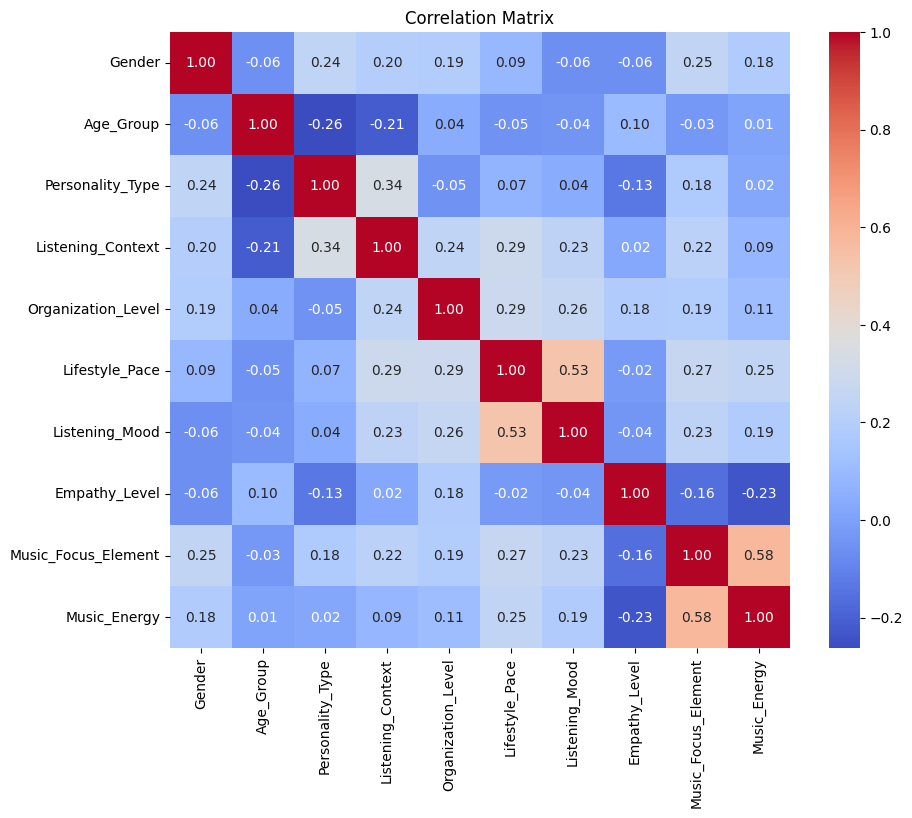

In [10]:
import seaborn as sns

numerical_df = df.select_dtypes(include = ['number'])

plt.figure(figsize = (10, 8))
sns.heatmap(numerical_df.corr(), annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

### 4. Model Training and Evaluation Strategy
#### 4.1 Train-Test Split & Scaling
We split the data into training and testing sets with a 75-25 split. We also apply `StandardScaler` to normalize the feature values, ensuring that features with larger ranges don't dominate the models.

In [11]:
from sklearn.model_selection import train_test_split

x = df.drop('Music_Energy', axis = 1)
y = df['Music_Energy']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

Training Data Shape: (84, 9)
Testing Data Shape: (28, 9)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#### 4.2 Evaluation Framework
We define a custom function `evaluate_and_log` to consistently track model performance. This function:
* Calculates **Accuracy**, **Precision**, **Recall**, and **F1 Score**.
* Checks for **Overfitting** (Training Score - Testing Score > 0.15).
* Checks for **Underfitting** (Training Score < 0.5).
* Plots the confusion matrices of models

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
model_performance = []

def evaluate_and_log(model_name, model, x_train, y_train, x_test, y_test, best_params):
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average = 'weighted', zero_division = 0)
    recall = recall_score(y_test, y_pred_test, average = 'weighted', zero_division = 0)
    f1 = f1_score(y_test, y_pred_test, average = 'weighted', zero_division = 0)

    train_score = accuracy_score(y_train, y_pred_train)
    test_score = accuracy
    gap = train_score - test_score
    
    print(f"--- {model_name} Results ---\n")
    print(f"Best Parameters:\n{best_params}\n")
    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Testing Accuracy:  {test_score:.4f}")
    print(f"Gap (Train - Test): {gap:.4f}")
    
    if gap > 0.15:
        print("⚠️ The Model may likely got overfitted!")
    elif train_score < 0.5:
        print("⚠️ The Model may likey got underfitted!")
    else:
        print("✅ The Model is fitted correctly!")
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred_test, zero_division=0))

    cm = confusion_matrix(y_test, y_pred_test)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    model_performance.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
    })

#### 4.3 Model Building and Testing

Gaussian Naive Bayes Model

--- Gaussian Naive Bayes Results ---

Best Parameters:
{'var_smoothing': np.float64(1e-05)}

Training Accuracy: 0.8095
Testing Accuracy:  0.7143
Gap (Train - Test): 0.0952
✅ The Model is fitted correctly!

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.77      0.71        13
           1       0.77      0.67      0.71        15

    accuracy                           0.71        28
   macro avg       0.72      0.72      0.71        28
weighted avg       0.72      0.71      0.71        28



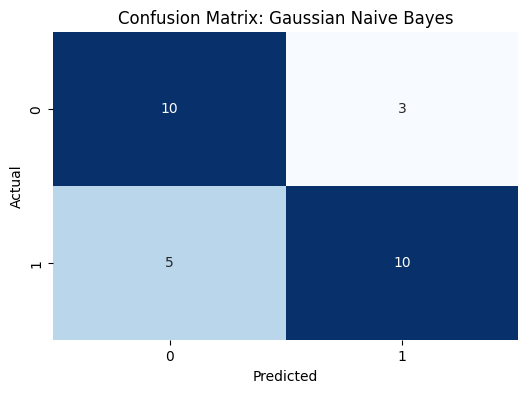

In [14]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

param_grid_nb = {
    'var_smoothing': np.logspace(-5, 2, 20)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv = cv_strategy, scoring = 'accuracy', n_jobs = -1)
grid_nb.fit(x_train_scaled, y_train)
evaluate_and_log("Gaussian Naive Bayes", grid_nb.best_estimator_, x_train_scaled, y_train, x_test_scaled, y_test, grid_nb.best_params_)

Logistic Regression Model

--- Logistic Regression Results ---

Best Parameters:
{'C': 0.1, 'max_iter': 1000, 'solver': 'liblinear'}

Training Accuracy: 0.8333
Testing Accuracy:  0.7500
Gap (Train - Test): 0.0833
✅ The Model is fitted correctly!

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74        13
           1       0.79      0.73      0.76        15

    accuracy                           0.75        28
   macro avg       0.75      0.75      0.75        28
weighted avg       0.75      0.75      0.75        28



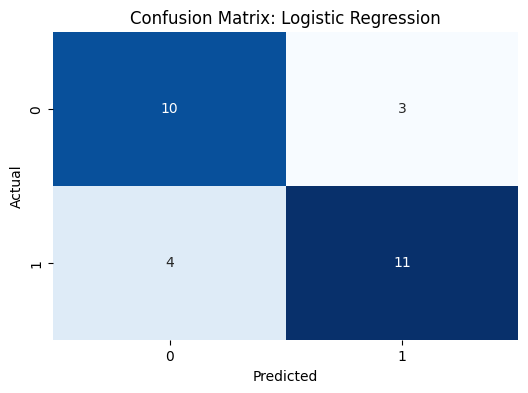

In [15]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000]
}

grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv = cv_strategy, scoring = 'accuracy', n_jobs = -1)
grid_lr.fit(x_train_scaled, y_train)
evaluate_and_log("Logistic Regression", grid_lr.best_estimator_, x_train_scaled, y_train, x_test_scaled, y_test, grid_lr.best_params_)

K-Nearest Neighbors Model

--- K-Nearest Neighbors Results ---

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}

Training Accuracy: 0.8333
Testing Accuracy:  0.7143
Gap (Train - Test): 0.1190
✅ The Model is fitted correctly!

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.69      0.69        13
           1       0.73      0.73      0.73        15

    accuracy                           0.71        28
   macro avg       0.71      0.71      0.71        28
weighted avg       0.71      0.71      0.71        28



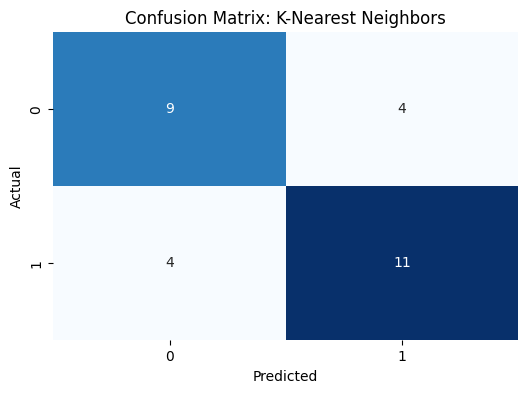

In [16]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [5, 7, 9, 11, 13, 15],
    'weights': ['uniform'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv = cv_strategy, scoring = 'accuracy', n_jobs = -1)
grid_knn.fit(x_train_scaled, y_train)
evaluate_and_log("K-Nearest Neighbors", grid_knn.best_estimator_, x_train_scaled, y_train, x_test_scaled, y_test, grid_knn.best_params_)

Support Vector Machine Model

--- Support Vector Machine Results ---

Best Parameters:
{'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}

Training Accuracy: 0.8214
Testing Accuracy:  0.7857
Gap (Train - Test): 0.0357
✅ The Model is fitted correctly!

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.85      0.79        13
           1       0.85      0.73      0.79        15

    accuracy                           0.79        28
   macro avg       0.79      0.79      0.79        28
weighted avg       0.79      0.79      0.79        28



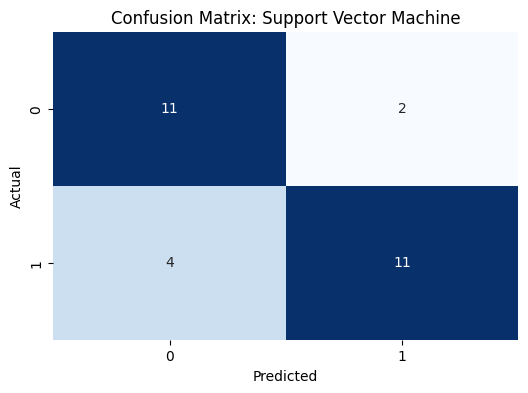

In [17]:
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 0.5, 1.0, 5.0, 10.0],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv = cv_strategy, scoring = 'accuracy', n_jobs = -1)
grid_svm.fit(x_train_scaled, y_train)
evaluate_and_log("Support Vector Machine", grid_svm.best_estimator_, x_train_scaled, y_train, x_test_scaled, y_test, grid_svm.best_params_)

Decision Tree Model

--- Decision Tree Results ---

Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 15}

Training Accuracy: 0.8571
Testing Accuracy:  0.7143
Gap (Train - Test): 0.1429
✅ The Model is fitted correctly!

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.85      0.73        13
           1       0.82      0.60      0.69        15

    accuracy                           0.71        28
   macro avg       0.73      0.72      0.71        28
weighted avg       0.74      0.71      0.71        28



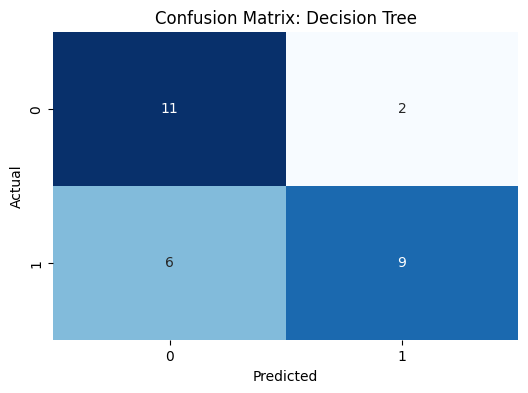

In [18]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4],      
    'min_samples_split': [15, 20, 25], 
    'min_samples_leaf': [5, 8, 10, 12]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state = 42), param_grid_dt, cv = cv_strategy, scoring = 'accuracy', n_jobs = -1)
grid_dt.fit(x_train_scaled, y_train)
evaluate_and_log("Decision Tree", grid_dt.best_estimator_, x_train_scaled, y_train, x_test_scaled, y_test, grid_dt.best_params_)

Random Forest Model

--- Random Forest Results ---

Best Parameters:
{'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 25, 'n_estimators': 100}

Training Accuracy: 0.8214
Testing Accuracy:  0.8214
Gap (Train - Test): 0.0000
✅ The Model is fitted correctly!

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.81        13
           1       0.86      0.80      0.83        15

    accuracy                           0.82        28
   macro avg       0.82      0.82      0.82        28
weighted avg       0.82      0.82      0.82        28



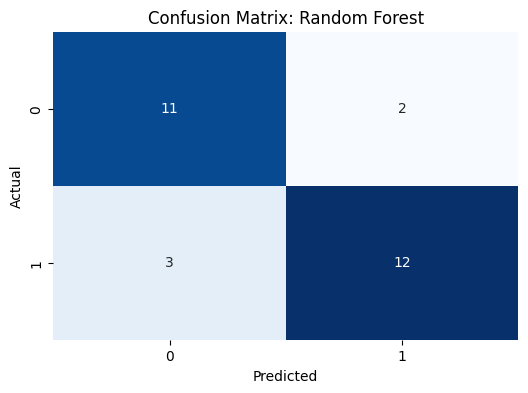

In [19]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [2, 3, 4],
    'min_samples_split': [10, 15, 20, 25],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
grid_rf.fit(x_train_scaled, y_train)
evaluate_and_log("Random Forest", grid_rf.best_estimator_, x_train_scaled, y_train, x_test_scaled, y_test, grid_rf.best_params_)

### 5. Model Performance Comparison
We compile the results into a dataframe and visualize the **Weighted F1 Score** of all models to determine the best performer, sorting by F1 Score and Accuracy.

In [20]:
performance_df = pd.DataFrame(model_performance)
performance_df = performance_df.sort_values(by = ['F1 Score', 'Accuracy'], ascending = False).reset_index(drop = True)

print("Model Performance Table:")
performance_df

Model Performance Table:


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.821429,0.823980,0.821429,0.821657
1,Support Vector Machine,0.785714,0.793773,0.785714,0.785714
2,Logistic Regression,0.750000,0.752551,0.750000,0.750319
3,Gaussian Naive Bayes,0.714286,0.721612,0.714286,0.714286
4,K-Nearest Neighbors,0.714286,0.714286,0.714286,0.714286
5,Decision Tree,0.714286,0.738732,0.714286,0.711355


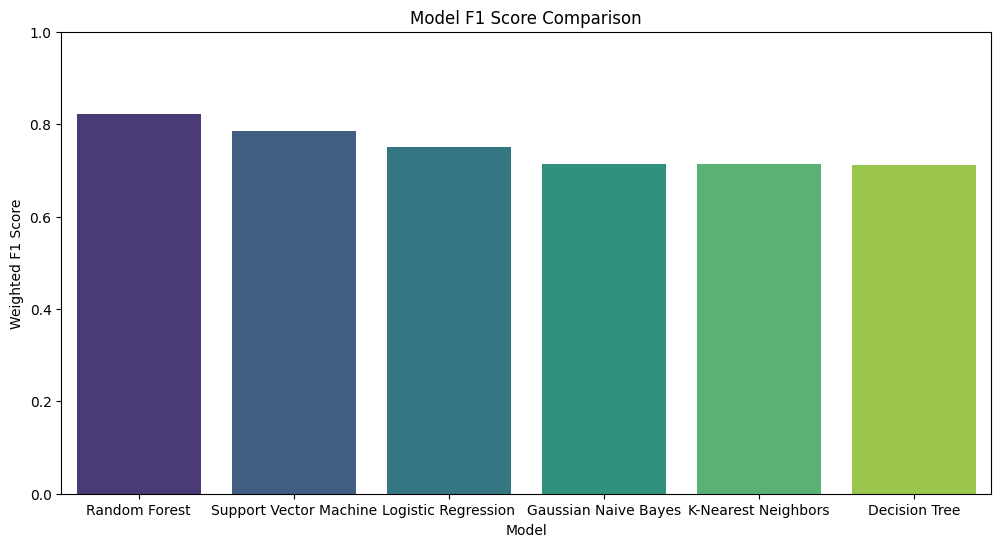

In [21]:
plt.figure(figsize = (12, 6))
sns.barplot(x = 'Model', y = 'F1 Score', data = performance_df, hue = 'Model', palette = 'viridis', legend = False)
plt.title('Model F1 Score Comparison')
plt.ylim(0, 1.0)
plt.ylabel("Weighted F1 Score")
plt.show()

### 6. Feature Importance Analysis
To understand why the models make their predictions, we analyze feature importance.
* For tree-based models (Random Forest, Decision Tree), we use built-in feature importance.
* For Logistic Regression, we use coefficient magnitude.
* For other models, we use Permutation Importance.

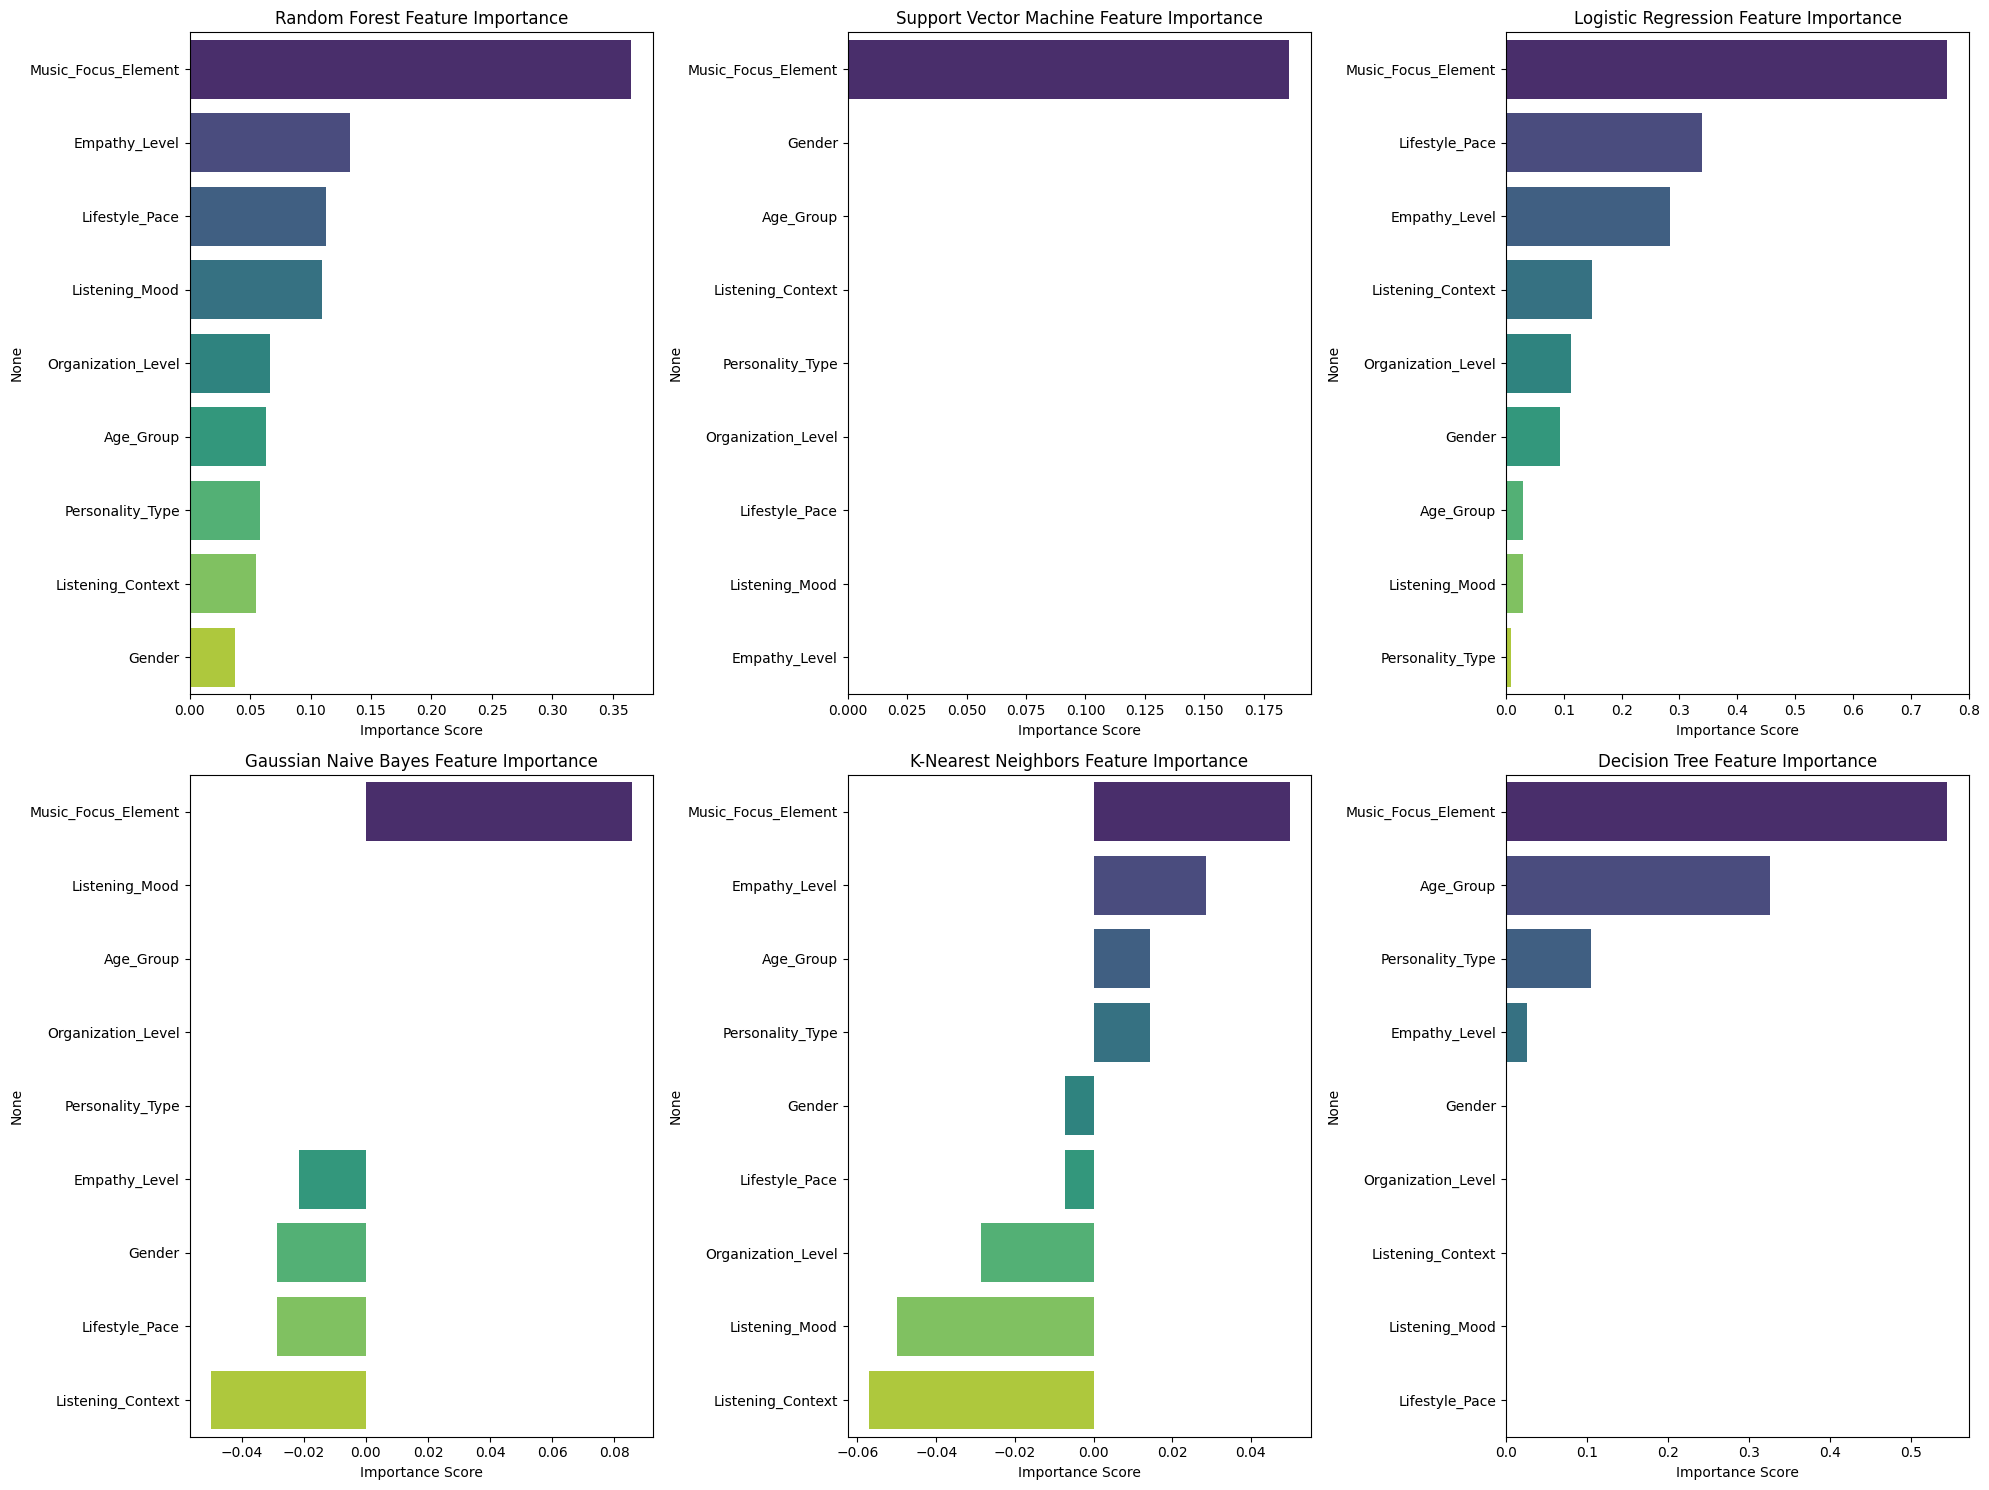

In [22]:
from sklearn.inspection import permutation_importance

rf_best = RandomForestClassifier(
    max_depth = 2, max_features = 'sqrt', min_samples_leaf = 2, min_samples_split = 25,
    n_estimators = 100, random_state = 42
)

svm_best = SVC(
    C = 1.0, gamma = 0.01, kernel = 'rbf', probability = True, random_state = 42
)

knn_best = KNeighborsClassifier(
    metric = 'manhattan', n_neighbors = 7, weights = 'uniform'
)

lr_best = LogisticRegression(
    C = 0.1, solver = 'liblinear', max_iter = 1000
)

dt_best = DecisionTreeClassifier(
    criterion = 'gini', max_depth = 3, min_samples_leaf = 5, min_samples_split =  15, random_state = 42
)

nb_best = GaussianNB(var_smoothing = 1e-05)

models = {
    "Random Forest": rf_best,
    "Support Vector Machine": svm_best,
    "Logistic Regression": lr_best,
    "Gaussian Naive Bayes": nb_best,
    "K-Nearest Neighbors": knn_best,
    "Decision Tree": dt_best
}

feature_names = x.columns

plt.figure(figsize = (20, 15))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(x_train_scaled, y_train)
    
    importance_values = []
    
    if hasattr(model, 'feature_importances_'):
        importance_values = model.feature_importances_
    elif hasattr(model, 'coef_') and name == "Logistic Regression":
        importance_values = np.abs(model.coef_[0])
    else:
        results = permutation_importance(model, x_test_scaled, y_test, scoring = 'accuracy', random_state = 42)
        importance_values = results.importances_mean

    feat_imp = pd.Series(importance_values, index = feature_names).sort_values(ascending = False)
    
    plt.subplot(2, 3, i)
    sns.barplot(x = feat_imp.values, y = feat_imp.index, hue = feat_imp.index, legend = False, palette = 'viridis')
    plt.title(f'{name} Feature Importance')
    plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

### 7. ROC Curve Analysis
We plot the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC) for all models. This graph illustrates the trade-off between True Positive Rate and False Positive Rate.

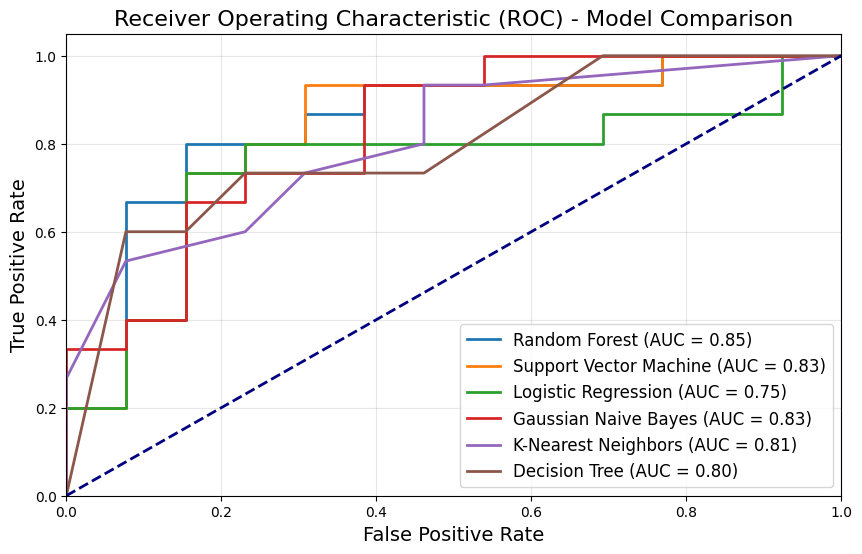

In [23]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize = (10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(x_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw = 2, label = f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize = 14)
plt.ylabel('True Positive Rate', fontsize = 14)
plt.title('Receiver Operating Characteristic (ROC) - Model Comparison', fontsize = 16)
plt.legend(loc = "lower right", fontsize = 12)
plt.grid(alpha = 0.3)
plt.show()

### 8. Prediction on new data
Finally, we test our best-performing model (Random Forest) on synthetic GenZ "personas" to see if the predictions logically map psychographic and behavioral profiles to music energy preferences:

1. **The Energetic Gym-Goer:** Extroverted, fast-paced lifestyle, works out often, focuses on the beat/rhythm, and is currently in an energetic mood.
2. **The Stressed Student:** High neuroticism, anxious, deeply empathetic, highly spontaneous schedule, and listens to music while studying.
3. **The Chill Creative:** High openness to experience, slow/relaxed lifestyle, focuses on lyrics, and listens while commuting or doing chores.
4. **The Organized Planner:** Conscientious, steady-paced, highly structured schedule, calm mood, focuses on the beat, and listens while working.
5. **The Sad & Empathetic Listener:** Agreeable, deeply empathetic, listens while trying to sleep, sad mood, and highly focused on lyrics and vocals.

In [24]:
new_data = [
    [0, 1, 2, 0, 1, 0, 1, 1, 0],
    [1, 0, 4, 2, 0, 0, 0, 0, 1],
    [1, 2, 0, 1, 0, 2, 3, 0, 1],
    [0, 3, 1, 2, 2, 1, 3, 1, 0],
    [1, 1, 3, 2, 1, 2, 2, 0, 1]
]

columns = ['Gender', 'Age_Group', 'Personality_Type', 'Listening_Context', 'Organization_Level', 
           'Lifestyle_Pace', 'Listening_Mood', 'Empathy_Level', 'Music_Focus_Element']

new_df = pd.DataFrame(new_data, columns=columns)
new_df_scaled = scaler.transform(new_df)

predictions = rf_best.predict(new_df_scaled)
probabilities = rf_best.predict_proba(new_df_scaled)

print("--- Prediction Results for New Users ---")
for i, pred in enumerate(predictions):
    if pred == 0:
        status = "High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)"
    else:
        status = "Low-Energy (Lo-Fi, Classical, Acoustic, Indie, R&B, etc.)"
    print(f"Person {i+1}: Predicted Music Energy = {status}")

--- Prediction Results for New Users ---
Person 1: Predicted Music Energy = High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)
Person 2: Predicted Music Energy = Low-Energy (Lo-Fi, Classical, Acoustic, Indie, R&B, etc.)
Person 3: Predicted Music Energy = Low-Energy (Lo-Fi, Classical, Acoustic, Indie, R&B, etc.)
Person 4: Predicted Music Energy = High-Energy (Pop, Hip-Hop, EDM, Rap, Rock, etc.)
Person 5: Predicted Music Energy = Low-Energy (Lo-Fi, Classical, Acoustic, Indie, R&B, etc.)
